<a href="https://colab.research.google.com/github/sultanjacob/Applied-Machine-Learning/blob/main/04_Affinity_Network_Analysis/01_Persona_Affinity_Mining_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 5: Affinity Network Analysis (Association Rules)

Standard Market Basket Analysis often yields obvious, low-value insights ( "if a person buys item A, they also buy item B".). In this notebook, we elevate the methodology by performing **Persona-Isolated Affinity Mining**. This is a data mining technique used to find hidden connections or "if-then" patterns between items in large datasets

By utilizing the Agglomerative Hierarchical clusters discovered in our previous unsupervised learning pipeline, we will run the **Apriori** and **FP-Growth** algorithms independently on distinct customer cohorts. Our goal is to discover unique combinatorial purchasing dynamics and visualize them using network graphs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules

# Set chart aesthetic
sns.set_theme(style="whitegrid")

# Load our master clustered dataset
df = pd.read_csv('master_customers_fully_clustered.csv')

print(f"Master dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
print("Available Clusters for Analysis:")
print(df['Hierarchical_Cluster'].value_counts())

Master dataset loaded: 801 rows, 20 columns.
Available Clusters for Analysis:
Hierarchical_Cluster
0    609
2    108
1     84
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Step 2: Re-Integrating the Transactional Data

Association Rule learning requires transactional data (baskets), not aggregated household data. We must load the original raw transactions, filter out the noise, and join them with our `Hierarchical_Cluster` labels. This allows us to isolate all the shopping baskets that belong exclusively to our target personas.

In [3]:
# Install the Dunnhumby Complete Journey dataset package
!pip install completejourney_py

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/31.6 MB ? eta -:--:--

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

   ━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/31.6 MB 6.3 MB/s eta 0:00:05

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 25.9 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [4]:
import pandas as pd
from completejourney_py import get_data

# Load all datasets into a dictionary
data = get_data()

# Extract the two specific tables we are going to merge and clean
transactions = data["transactions"]
demographics = data["demographics"]

print(f"Loaded {len(transactions):,} transaction records")
print(f"Covering {len(demographics):,} households")

# Let's peek at the chaos
display(transactions.head())
display(demographics.head())

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Loaded 1,469,307 transaction records
Covering 801 households


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,household_id,store_id,basket_id,product_id,quantity,sales_value,retail_disc,coupon_disc,coupon_match_disc,week,transaction_timestamp
0,900,330,31198570044,1095275,1,0.50,0.00,0.0,0.0,1,2017-01-01 11:53:26
1,900,330,31198570047,9878513,1,0.99,0.10,0.0,0.0,1,2017-01-01 12:10:28
2,1228,406,31198655051,1041453,1,1.43,0.15,0.0,0.0,1,2017-01-01 12:26:30
3,906,319,31198705046,1020156,1,1.50,0.29,0.0,0.0,1,2017-01-01 12:30:27
4,906,319,31198705046,1053875,2,2.78,0.80,0.0,0.0,1,2017-01-01 12:30:27


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,household_id,age,income,home_ownership,marital_status,household_size,household_comp,kids_count
0,1,65+,35-49K,Homeowner,Married,2,2 Adults No Kids,0
1,1001,45-54,50-74K,Homeowner,Unmarried,1,1 Adult No Kids,0
2,1003,35-44,25-34K,None,Unmarried,1,1 Adult No Kids,0
3,1004,25-34,15-24K,None,Unmarried,1,1 Adult No Kids,0
4,101,45-54,Under 15K,Homeowner,Married,4,2 Adults Kids,2


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [6]:
# 1. Extract the specific tables we need from the get_data() dictionary
transactions = data["transactions"]
products = data["products"]

# 2. Merge OUR custom cluster labels onto the raw transactions
# This filters the millions of rows down to just the households we successfully clustered
basket_data = transactions.merge(df[['household_id', 'Hierarchical_Cluster']], on='household_id', how='inner')

# 3. Merge the product descriptions onto our baskets so we can read the item names
basket_data = basket_data.merge(products, on='product_id', how='left')

# 4. Let's look at the shape of our new hybrid dataset
print(f"Total Transactions mapped to Clusters: {basket_data.shape[0]:,}")
print("\nColumns available for our baskets:")
print(basket_data.columns.tolist())

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Total Transactions mapped to Clusters: 828,850

Columns available for our baskets:
['household_id', 'store_id', 'basket_id', 'product_id', 'quantity', 'sales_value', 'retail_disc', 'coupon_disc', 'coupon_match_disc', 'week', 'transaction_timestamp', 'Hierarchical_Cluster', 'manufacturer_id', 'department', 'brand', 'product_category', 'product_type', 'package_size']


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

### Step 3: Engineering the One-Hot Encoded Matrix

Association rule algorithms cannot read standard transactional data. They require a bipartite matrix where:
*   Every **row** is a unique shopping trip (`basket_id`).
*   Every **column** is a unique item (`product_category`).
*   The **values** are strictly `1` (the item was in the basket) or `0` (the item was not).

We will begin by isolating **Cluster 1** (The Loyal Power Shoppers) and pivoting their thousands of transactions into this specific mathematical structure.

In [7]:
# 1. Isolate the transactions for just our Power Shoppers (Cluster 1)
cluster_1_data = basket_data[basket_data['Hierarchical_Cluster'] == 1]

print(f"Total raw transactions for Cluster 1: {cluster_1_data.shape[0]:,}")

# 2. Pivot the data: group by basket and category, sum the quantities, and unstack
# This creates a grid of Baskets (rows) vs Categories (columns)
basket = (cluster_1_data
          .groupby(['basket_id', 'product_category'])['quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('basket_id'))

# 3. The Apriori algorithm requires strictly boolean values (1 or 0)
# Even if they bought 5 milks, the algorithm just needs to know milk was in the basket (1)
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

# Apply our encoding function to the entire matrix
basket_sets = basket.apply(lambda x: x.map(encode_units))

# 4. Check our final matrix shape
print(f"Matrix created: {basket_sets.shape[0]:,} unique shopping trips containing {basket_sets.shape[1]:,} unique product categories.")

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Total raw transactions for Cluster 1: 187,423


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Matrix created: 20,577 unique shopping trips containing 291 unique product categories.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

### Step 4: Applying Apriori and Extracting Rules

We will pass our one-hot encoded matrix into the `apriori` algorithm to find frequent itemsets (combinations of items that appear in at least 3% of all trips).

Once we have the frequent itemsets, we use the `association_rules` function to calculate the core metrics: **Support**, **Confidence**, and **Lift**. We will filter our results to only show rules with a Lift strictly greater than 1.2, ensuring we are only looking at products that have a strong, mathematically proven gravitational pull toward one another.

In [8]:
# 1. Find frequent itemsets (must appear in at least 3% of all trips)
# The use_colnames=True argument ensures we see text names, not column index numbers
frequent_itemsets = apriori(basket_sets, min_support=0.03, use_colnames=True)

# 2. Generate the rules and filter by a minimum Lift of 1.2
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# 3. Sort the results by Lift (highest business value/correlation first)
top_rules = rules.sort_values('lift', ascending=False)

# 4. Display the top 10 most powerful product combinations for our Power Shoppers
print(f"Algorithm discovered {rules.shape[0]} high-value association rules for Cluster 1.")
display(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).round(3))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Algorithm discovered 332 high-value association rules for Cluster 1.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,support,confidence,lift
308,"(FLUID MILK PRODUCTS, CHEESE)",(EGGS),0.032,0.413,5.097
313,(EGGS),"(FLUID MILK PRODUCTS, CHEESE)",0.032,0.398,5.097
236,"(BAKED BREAD/BUNS/ROLLS, CHEESE)",(EGGS),0.032,0.401,4.942
241,(EGGS),"(BAKED BREAD/BUNS/ROLLS, CHEESE)",0.032,0.391,4.942
277,(EGGS),"(BAKED BREAD/BUNS/ROLLS, FLUID MILK PRODUCTS)",0.038,0.471,4.775
272,"(BAKED BREAD/BUNS/ROLLS, FLUID MILK PRODUCTS)",(EGGS),0.038,0.387,4.775
260,"(BAKED BREAD/BUNS/ROLLS, FLUID MILK PRODUCTS)",(COLD CEREAL),0.035,0.353,4.690
265,(COLD CEREAL),"(BAKED BREAD/BUNS/ROLLS, FLUID MILK PRODUCTS)",0.035,0.462,4.690
283,(REFRGRATD JUICES/DRNKS),"(BAKED BREAD/BUNS/ROLLS, FLUID MILK PRODUCTS)",0.032,0.461,4.682
278,"(BAKED BREAD/BUNS/ROLLS, FLUID MILK PRODUCTS)",(REFRGRATD JUICES/DRNKS),0.032,0.322,4.682


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

### Step 5: Visualizing Business Impact

Complex matrices and network graphs can obscure the core business narrative. To make these insights immediately actionable for retail stakeholders, we translate the association rules into a **Business Impact Bar Chart**.

This visualization uses plain English to describe the product flow (Antecedent ➔ Consequent) and ranks the combinations by their **Lift**, showing exactly how many times more likely a customer is to purchase the resulting item.

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

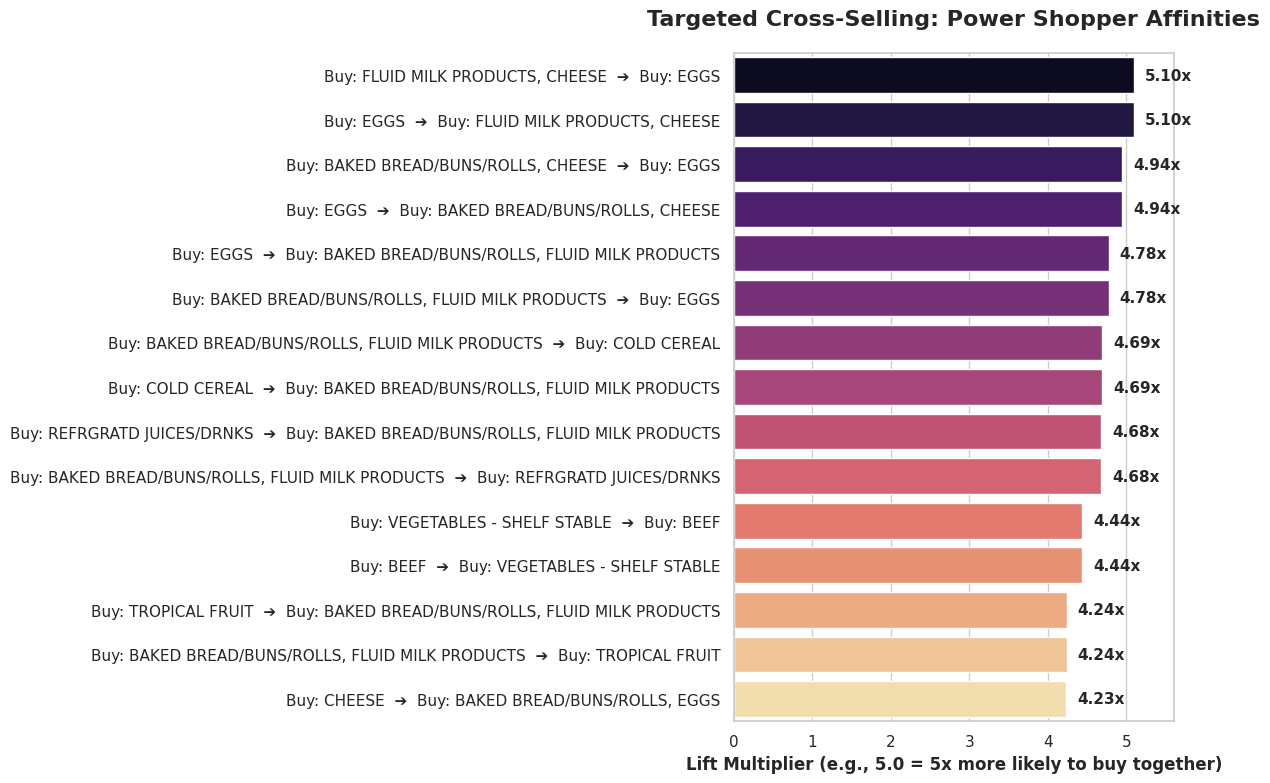

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [11]:
# 1. Take the top 15 rules to keep the chart clean and focused
bar_rules = top_rules.head(15).copy()

# 2. Translate the sets into plain English labels
bar_rules['rule_label'] = bar_rules.apply(
    lambda x: f"Buy: {', '.join(list(x['antecedents']))}  ➔  Buy: {', '.join(list(x['consequents']))}", axis=1
)

# 3. Set up a clean, wide canvas
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 4. Draw the horizontal bar chart
ax = sns.barplot(
    data=bar_rules,
    y='rule_label',
    x='lift',
    palette='magma' # A striking, professional gradient
)

# 5. Clean up the titles and axes
plt.title('Targeted Cross-Selling: Power Shopper Affinities', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Lift Multiplier (e.g., 5.0 = 5x more likely to buy together)', fontsize=12, fontweight='bold')
plt.ylabel('') # Remove y-axis label since the text explains itself

# 6. Annotate the exact multiplier directly onto the bars for instant readability
for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}x",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(8, 0), textcoords='offset points',
                fontweight='bold', fontsize=11)

# Extend the x-axis slightly so the text annotations don't get cut off
plt.xlim(0, bar_rules['lift'].max() * 1.1)

plt.tight_layout()
plt.show()

### Step 6: Comparative Affinity (Premium Shoppers)

To prove the value of Persona-Isolated Affinity Mining, we will now run the exact same Apriori pipeline on **Cluster 2 (Premium Shoppers)**.

By comparing the top Lift multipliers of this higher-income, higher-basket-value segment against our Power Shoppers, we can identify demographic-specific cross-selling opportunities.

In [12]:
# 1. Isolate the transactions for Premium Shoppers (Cluster 2)
cluster_2_data = basket_data[basket_data['Hierarchical_Cluster'] == 2]
print(f"Total raw transactions for Cluster 2: {cluster_2_data.shape[0]:,}")

# 2. Pivot the data into the One-Hot Encoded Matrix
basket_2 = (cluster_2_data
          .groupby(['basket_id', 'product_category'])['quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('basket_id'))

# 3. Apply the boolean encoding (1 or 0)
basket_sets_2 = basket_2.apply(lambda x: x.map(encode_units))

# 4. Run Apriori and Association Rules
# We use the same 3% minimum support threshold for a fair comparison
frequent_itemsets_2 = apriori(basket_sets_2, min_support=0.03, use_colnames=True)
rules_2 = association_rules(frequent_itemsets_2, metric="lift", min_threshold=1.2)
top_rules_2 = rules_2.sort_values('lift', ascending=False)

# 5. Display the top 10 most powerful product combinations for Premium Shoppers
print(f"\nAlgorithm discovered {rules_2.shape[0]} high-value association rules for Cluster 2.")
display(top_rules_2[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).round(3))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Total raw transactions for Cluster 2: 123,258


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac


Algorithm discovered 1908 high-value association rules for Cluster 2.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
366,(CHEESES),(DELI MEATS),0.030,0.667,8.738
367,(DELI MEATS),(CHEESES),0.030,0.398,8.738
451,(DRY NOODLES/PASTA),(PASTA SAUCE),0.031,0.476,7.866
450,(PASTA SAUCE),(DRY NOODLES/PASTA),0.031,0.519,7.866
550,(VEGETABLES - SHELF STABLE),(FRUIT - SHELF STABLE),0.033,0.338,4.547
551,(FRUIT - SHELF STABLE),(VEGETABLES - SHELF STABLE),0.033,0.438,4.547
1521,(COLD CEREAL),"(FLUID MILK PRODUCTS, CONVENIENT BRKFST/WHLSM ...",0.035,0.262,4.207
1516,"(FLUID MILK PRODUCTS, CONVENIENT BRKFST/WHLSM ...",(COLD CEREAL),0.035,0.569,4.207
1332,"(CHEESE, BEEF)",(VEGETABLES - SHELF STABLE),0.031,0.404,4.196
1333,(VEGETABLES - SHELF STABLE),"(CHEESE, BEEF)",0.031,0.318,4.196


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

### Explanation:
**Look at our top two rules: CHEESES ➔ DELI MEATS.**

Not only is this a completely different product pairing than our first cluster, but look at the Lift (8.738). That is astronomical. If a Premium Shopper buys specialty cheese, they are almost 9 times more likely to walk over to the deli counter. This isn't a family stocking up on milk and eggs; this is a high-margin, experiential meal purchase.

**🍝 The "Dinner Solution"**

Our next highest pairing is DRY NOODLES/PASTA ➔ PASTA SAUCE (Lift 7.866). Again, this cluster is shopping for specific, cohesive dinner solutions, whereas Cluster 1 was executing a massive, general breakfast and dairy restock.